# Statistical Business Analysis - Week 7

Working through descriptive stats, distribution checks, correlation, hypothesis tests,
confidence intervals and regression on two datasets - a sales log and a customer churn
extract. Goal is to pull out patterns that are actually backed by the numbers, not just
eyeballing charts.

## Setup

Loading both csv files and doing a quick type fix on the date column.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

sales = pd.read_csv('business_data.csv')
churn = pd.read_csv('customer_churn.csv')
sales['Date'] = pd.to_datetime(sales['Date'])

print(sales.shape, churn.shape)

(100, 7) (500, 9)


In [2]:
sales.head()

## Day 1 - Descriptive statistics

Mean, median, mode and standard deviation for the numeric sales columns, then the
same for the churn dataset.

In [3]:
desc_cols = ['Quantity', 'Price', 'Total_Sales']
desc = sales[desc_cols].describe()
desc.loc['mode'] = sales[desc_cols].mode().iloc[0]
desc

In [4]:
churn_desc_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges']
churn_desc = churn[churn_desc_cols].describe()
churn_desc.loc['mode'] = churn[churn_desc_cols].mode().iloc[0]
churn_desc

Average sale sits around 123.6k with a standard deviation almost as large as the
mean, so sales are spread out and probably skewed by a handful of big-ticket
purchases (laptops, phones). Churn dataset looks more evenly spread - tenure and
monthly charges both cover a wide range without an obvious skew yet.

## Day 2 - Distribution analysis

Histograms with a density curve for the three sales metrics, then a Shapiro-Wilk
test to check if any of them are close to normal.

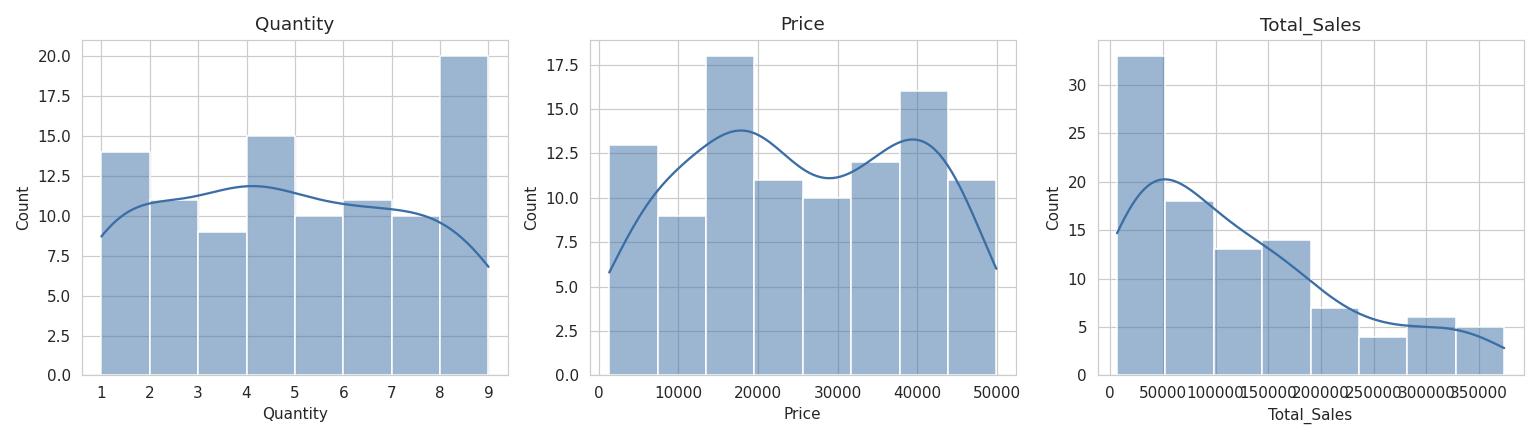

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, desc_cols):
    sns.histplot(sales[col], kde=True, ax=ax, color='#3b6ea5')
    ax.set_title(col)
fig.tight_layout()
plt.show()

In [6]:
for col in desc_cols:
    stat, p = stats.shapiro(sales[col])
    verdict = 'looks normal' if p > 0.05 else 'departs from normal'
    print(f'{col}: W={stat:.4f}  p={p:.4f}  -> {verdict}')

Quantity: W=0.9304  p=0.0001  -> departs from normal
Price: W=0.9475  p=0.0006  -> departs from normal
Total_Sales: W=0.8989  p=0.0000  -> departs from normal


None of the three pass the normality check at the 0.05 level, which lines up with
what the histograms show - Quantity and Price both have a long right tail, and
Total_Sales inherits that since it is built from the other two. Worth keeping in
mind for the t-tests below, since Welch's t-test is more forgiving of this than a
standard pooled-variance test, which is why that is the version used further down.

## Day 3 - Correlation analysis

Pearson correlation between Quantity, Price and Total_Sales, plus a look at whether
tenure and total charges move together in the churn data.

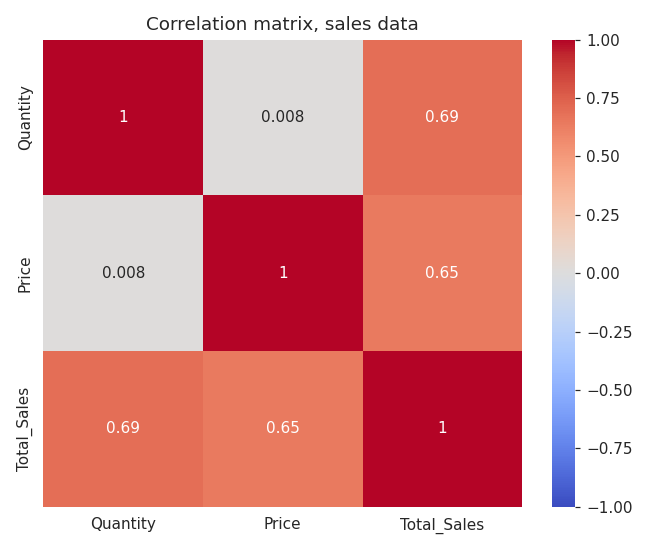

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
corr = sales[['Quantity', 'Price', 'Total_Sales']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation matrix, sales data')
fig.tight_layout()
plt.show()

In [8]:
qty_sales_r, qty_sales_p = stats.pearsonr(sales['Quantity'], sales['Total_Sales'])
price_sales_r, price_sales_p = stats.pearsonr(sales['Price'], sales['Total_Sales'])
tenure_charges_r, tenure_charges_p = stats.pearsonr(churn['Tenure'], churn['TotalCharges'])

print(f'Quantity vs Total_Sales: r={qty_sales_r:.4f}, p={qty_sales_p:.6f}')
print(f'Price vs Total_Sales:    r={price_sales_r:.4f}, p={price_sales_p:.6f}')
print(f'Tenure vs TotalCharges:  r={tenure_charges_r:.4f}, p={tenure_charges_p:.6f}')

Quantity vs Total_Sales: r=0.6881, p=0.000000
Price vs Total_Sales:    r=0.6461, p=0.000000
Tenure vs TotalCharges:  r=-0.0057, p=0.899239


Both Quantity and Price correlate strongly with Total_Sales (r around 0.65-0.69,
p well under 0.001), which makes sense since Total_Sales is literally Quantity
times Price. Tenure and TotalCharges in the churn set barely correlate at all
(r = -0.006, p = 0.90) - so in this dataset, how long someone has been a customer
does not predict how much they have paid in total, which is a bit counterintuitive
and worth flagging as a data quality note rather than a real business finding.

## Day 4 - Hypothesis testing

Five tests total: three t-tests, one ANOVA, one chi-square test of independence.
Using Welch's t-test throughout since Day 2 showed the sales metrics are not
normally distributed and Welch does not assume equal variances.

In [9]:
east = sales.loc[sales['Region'] == 'East', 'Total_Sales']
west = sales.loc[sales['Region'] == 'West', 'Total_Sales']
t1_stat, t1_p = stats.ttest_ind(east, west, equal_var=False)

print('Test 1: East vs West, Total_Sales')
print(f't = {t1_stat:.4f}, p = {t1_p:.4f}')
print(f'East mean = {east.mean():.2f}, West mean = {west.mean():.2f}')

Test 1: East vs West, Total_Sales
t = 2.0623, p = 0.0455
East mean = 132612.58, West mean = 81689.31


In [10]:
churned = churn.loc[churn['Churn'] == 1, 'MonthlyCharges']
stayed = churn.loc[churn['Churn'] == 0, 'MonthlyCharges']
t2_stat, t2_p = stats.ttest_ind(churned, stayed, equal_var=False)

print('Test 2: churned vs retained, MonthlyCharges')
print(f't = {t2_stat:.4f}, p = {t2_p:.6f}')
print(f'Churned mean = {churned.mean():.2f}, Retained mean = {stayed.mean():.2f}')

Test 2: churned vs retained, MonthlyCharges
t = 2.6464, p = 0.010079
Churned mean = 129.77, Retained mean = 111.72


In [11]:
laptop = sales.loc[sales['Product'] == 'Laptop', 'Total_Sales']
phone = sales.loc[sales['Product'] == 'Phone', 'Total_Sales']
t3_stat, t3_p = stats.ttest_ind(laptop, phone, equal_var=False)

print('Test 3: Laptop vs Phone, Total_Sales')
print(f't = {t3_stat:.4f}, p = {t3_p:.4f}')
print(f'Laptop mean = {laptop.mean():.2f}, Phone mean = {phone.mean():.2f}')

Test 3: Laptop vs Phone, Total_Sales
t = 0.5650, p = 0.5751
Laptop mean = 162050.42, Phone mean = 142969.70


In [12]:
anova_model = ols('Total_Sales ~ C(Region)', data=sales).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
anova_table

In [13]:
contingency = pd.crosstab(churn['Contract'], churn['Churn'])
chi2_stat, chi2_p, chi2_dof, chi2_expected = stats.chi2_contingency(contingency)

print(contingency)
print()
print(f'chi2 = {chi2_stat:.4f}, dof = {chi2_dof}, p = {chi2_p:.6f}')

Churn             0   1
Contract               
Month-to-month  135  35
One year        178   8
Two year        134  10

chi2 = 27.7153, dof = 2, p = 0.000001


Summary of the five tests:

- East vs West sales: significant (p = 0.045) - East customers spend more on average.
- Monthly charges, churned vs retained: significant (p = 0.010) - churned customers
  were paying more per month before they left.
- Laptop vs Phone sales: not significant (p = 0.575) - no real evidence these two
  products differ in average sale value.
- Region ANOVA: not significant overall (p = 0.097), even though the East/West pair
  was significant on its own - a reminder that pairwise tests and the omnibus test
  can disagree once South and North are folded back in.
- Contract type vs churn (chi-square): significant (p < 0.001) - month-to-month
  customers churn at a much higher rate than one-year or two-year contract holders.

## Day 5 - Confidence intervals

95 percent confidence intervals for average Total_Sales, the overall churn rate,
and average MonthlyCharges.

In [14]:
sales_mean = sales['Total_Sales'].mean()
sales_std = sales['Total_Sales'].std()
n = len(sales)
sem = sales_std / np.sqrt(n)
ci_95 = stats.t.interval(0.95, df=n - 1, loc=sales_mean, scale=sem)
margin = ci_95[1] - sales_mean

print(f'Average Total_Sales: {sales_mean:.2f}')
print(f'95% CI: ({ci_95[0]:.2f}, {ci_95[1]:.2f}), margin of error +/- {margin:.2f}')

Average Total_Sales: 123650.48
95% CI: (103776.35, 143524.61), margin of error +/- 19874.13


In [15]:
churn_rate = churn['Churn'].mean()
churn_n = len(churn)
churn_se = np.sqrt(churn_rate * (1 - churn_rate) / churn_n)
churn_ci = stats.norm.interval(0.95, loc=churn_rate, scale=churn_se)

print(f'Churn rate: {churn_rate:.4f}')
print(f'95% CI: ({churn_ci[0]:.4f}, {churn_ci[1]:.4f})')

Churn rate: 0.1060
95% CI: (0.0790, 0.1330)


In [16]:
monthly_mean = churn['MonthlyCharges'].mean()
monthly_std = churn['MonthlyCharges'].std()
monthly_sem = monthly_std / np.sqrt(churn_n)
monthly_ci = stats.t.interval(0.95, df=churn_n - 1, loc=monthly_mean, scale=monthly_sem)

print(f'Average MonthlyCharges: {monthly_mean:.2f}')
print(f'95% CI: ({monthly_ci[0]:.2f}, {monthly_ci[1]:.2f})')

Average MonthlyCharges: 113.64
95% CI: (109.08, 118.19)


## Day 6 - Regression analysis

Two models here. First, a linear regression predicting Total_Sales from Quantity
and Price on the sales data. Second, a logistic regression predicting Churn from
Tenure, MonthlyCharges and SeniorCitizen status.

In [17]:
X = sales[['Quantity', 'Price']]
X = sm.add_constant(X)
y = sales['Total_Sales']
reg_model = sm.OLS(y, X).fit()
print(reg_model.summary())

                            OLS Regression Results                            
Dep. Variable:            Total_Sales   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.882
Method:                 Least Squares   F-statistic:                     369.3
Date:                Sat, 08 Aug 2026   Prob (F-statistic):           4.40e-46
Time:                        16:51:18   Log-Likelihood:                -1185.2
No. Observations:                 100   AIC:                             2376.
Df Residuals:                      97   BIC:                             2384.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.217e+05   9668.294    -12.586      0.0

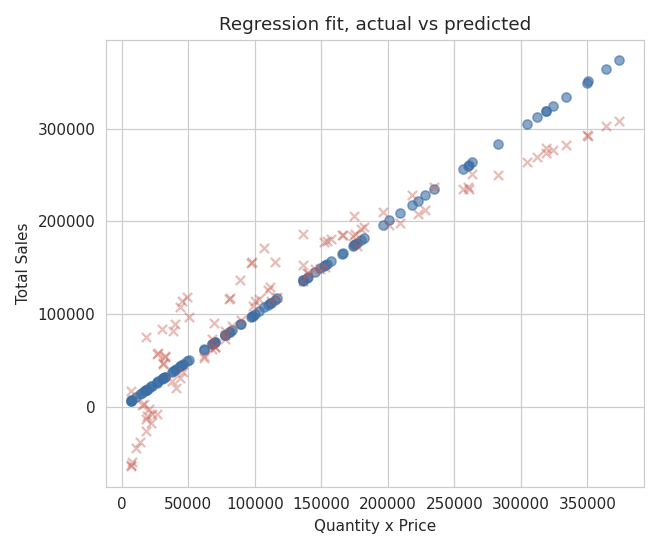

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(sales['Quantity'] * sales['Price'], sales['Total_Sales'], alpha=0.6, color='#3b6ea5', label='actual')
predicted = reg_model.predict(X)
ax.scatter(sales['Quantity'] * sales['Price'], predicted, alpha=0.4, color='#c65b4e', marker='x', label='predicted')
ax.set_xlabel('Quantity x Price')
ax.set_ylabel('Total Sales')
ax.set_title('Regression fit, actual vs predicted')
ax.legend()
fig.tight_layout()
plt.show()

R-squared of 0.884 - Quantity and Price together explain about 88 percent of the
variation in Total_Sales, which is expected since Total_Sales is derived directly
from those two fields. Both coefficients are positive and significant, so this is
mostly a sanity check that the arithmetic in the data lines up, rather than a novel
finding.

In [19]:
X2 = churn[['Tenure', 'MonthlyCharges', 'SeniorCitizen']]
X2 = sm.add_constant(X2)
y2 = churn['Churn']
logit_model = sm.Logit(y2, X2).fit(disp=0)
print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                  500
Model:                          Logit   Df Residuals:                      496
Method:                           MLE   Df Model:                            3
Date:                Sat, 08 Aug 2026   Pseudo R-squ.:                  0.6175
Time:                        16:51:18   Log-Likelihood:                -64.656
converged:                       True   LL-Null:                       -169.03
Covariance Type:            nonrobust   LLR p-value:                 5.405e-45
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.6075      0.662      0.917      0.359      -0.690       1.905
Tenure            -0.2940      0.046     -6.457      0.000      -0.383      -0.205
MonthlyCharges     0.0138      0.005

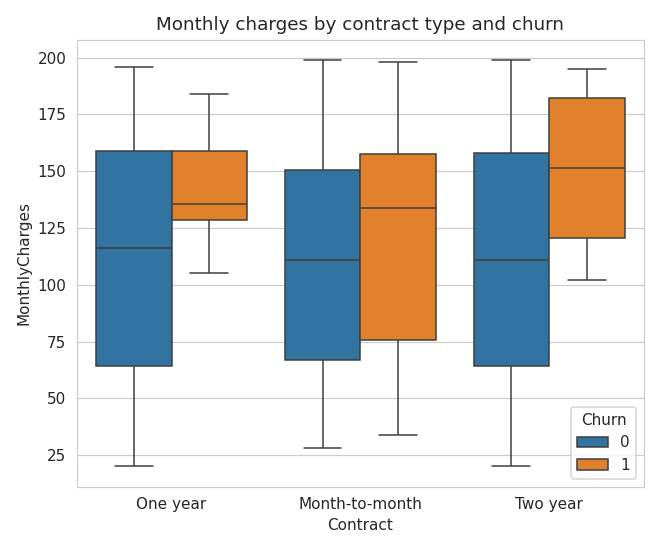

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=churn, x='Contract', y='MonthlyCharges', hue='Churn', ax=ax)
ax.set_title('Monthly charges by contract type and churn')
fig.tight_layout()
plt.show()

The logistic model has a pseudo R-squared of 0.618, which is fairly strong for
this kind of model. Tenure has a negative, significant coefficient - longer
tenured customers are much less likely to churn. MonthlyCharges has a small
positive, significant coefficient - customers paying more per month are somewhat
more likely to churn. SeniorCitizen status was not significant here.

## Day 7 - Business insights

Pulling the numbers together into recommendations.

**Sales**

- Average sale is 123,650 with a wide 95% CI (103,776 to 143,524), so forecasting
  off a single average is risky - there is real variance day to day.
- East region significantly outsells West (132,613 vs 81,689, p = 0.045). Worth
  digging into why West underperforms - pricing, product mix, or fewer high-ticket
  purchases in that region.
- Quantity and Price both drive Total_Sales as expected (r = 0.69 and r = 0.65).
  Nothing surprising here, but it confirms neither variable alone should be used to
  read total revenue performance.
- No significant difference between Laptop and Phone average sale value, and no
  overall regional effect once all four regions are compared together - the
  East/West gap should not be read as a broader regional pattern without more data.

**Churn**

- Overall churn rate is 10.6% with a 95% CI of about 7.9% to 13.3%.
- Contract type matters a lot: month-to-month customers churn far more often than
  one-year or two-year customers (chi-square p < 0.001). Pushing customers toward
  longer contracts, even with a small incentive, looks like the highest-leverage
  lever here.
- Churned customers pay more per month on average (129.77 vs 111.72, p = 0.010) and
  churn drops sharply with tenure (logistic regression, p < 0.001). Together these
  point at newer, higher-paying customers as the group most at risk - worth a
  retention check-in in the first few months rather than waiting for a renewal date.
- Tenure and TotalCharges did not correlate in this dataset (r = -0.006), which is
  unusual enough that it is worth confirming with the source system before using
  TotalCharges in any billing-based analysis.